## CTC Prediction for New Joiners

#### Importing the necessary modules

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Loading the dataset into pandas dataframe using read_csv() method

In [3]:
df = pd.read_csv("C:/Users/arnab/Downloads/Data Science PGC/Machine Learning/Project/Dataset/ML case Study.csv", header = 0)

In [4]:
# Displaying the first 5 rows of the data frame

In [5]:
df.head()

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,SVNIT Surat,Asansol,Manager,55523.0,3,66,19,71406.58
1,NIT Bhopal,Ajmer,Executive,57081.0,1,84,18,68005.87
2,"IEM, Kolkata",Rajpur Sonarpur,Executive,60347.0,2,52,28,76764.02
3,"KIIT, Bhubaneswar",Ajmer,Executive,49010.0,2,81,33,82092.39
4,DTU,Durgapur,Executive,57879.0,4,74,32,73878.10


In [6]:
# Displaying the column name, data type, no. of columns, no.of missing values of all categorical and numerical columns

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   College              1589 non-null   object 
 1   City                 1589 non-null   object 
 2   Role                 1589 non-null   object 
 3   Previous CTC         1589 non-null   float64
 4   Previous job change  1589 non-null   int64  
 5   Graduation Marks     1589 non-null   int64  
 6   EXP (Month)          1589 non-null   int64  
 7   CTC                  1589 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 99.4+ KB


In [8]:
# displaying the mean, median, minimum, maximum and quartile values of the numerical columns

In [9]:
df.describe()

,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
count,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000
mean,55518.453744,2.528634,59.855255,39.044682,75353.278798
std,6655.218445,1.123918,14.935139,14.108875,12587.288237
min,36990.000000,1.000000,35.000000,18.000000,53020.320000
25%,50518.000000,2.000000,46.000000,26.000000,66902.350000
50%,55291.000000,3.000000,60.000000,39.000000,73028.670000
75%,60109.000000,4.000000,73.000000,51.000000,80588.670000
max,77911.000000,4.000000,85.000000,64.000000,123416.990000


In [10]:
colleges = pd.read_csv("C:/Users/arnab/Downloads/Data Science PGC/Machine Learning/Project/Dataset/Colleges.csv", header=0)

In [11]:
colleges.head()

,Tier 1,Tier 2,Tier 3
0,IIT Bombay,IIIT Bangalore,"Ramaiah Institute of Technology, Bengaluru"
1,IIT Delhi,IIIT Delhi,TIET/Thapar University
2,IIT Kharagpur,IGDTUW,Manipal Main Campus
3,IIT Madras,NIT Calicut,VIT Vellore
4,IIT Kanpur,IIITM Gwalior,SRM Main Campus


In [12]:
cities = pd.read_csv("C:/Users/arnab/Downloads/Data Science PGC/Machine Learning/Project/Dataset/cities.csv", header = 0)

In [13]:
cities.head()

,Metrio City,non-metro cities
0,Mumbai,Dehradun
1,Delhi,Durgapur
2,Kolkata,Asansol
3,Chennai,Rourkela
4,Bangalore,Kozhikode


In [14]:
# Converting all the columns of colleges dataframe into corresponding lists

In [15]:
Tier1 = list(colleges['Tier 1'])

In [16]:
Tier2 = list(colleges['Tier 2'])

In [17]:
Tier3 = list(colleges['Tier 3'])

In [18]:
# Displaying the elements of the list

In [19]:
Tier3

['Ramaiah Institute of Technology, Bengaluru',
 'TIET/Thapar University',
 'Manipal Main Campus',
 'VIT Vellore',
 'SRM Main Campus',
 'KIIT, Bhubaneswar',
 'Amity University',
 'BMS College, Bangalore',
 'PES University, Bangalore',
 'USIT, Delhi',
 'MAIT, Delhi',
 'MSIT, Delhi',
 'Dayanand College of Engineering, Bangalore',
 'Heritage Institute of Technology, Kolkata',
 'IEM, Kolkata',
 'Techno India, Kolkata',
 'Jaypee, Noida',
 'Amrita University, Coimbatore',
 'Cummins College of Engineering for Women, Pune',
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan]

In [20]:
# Converting all the columns of cities dataframe into corresponding lists

In [21]:
metro = list(cities['Metrio City'])

In [22]:
non_metro = list(cities['non-metro cities'])

In [23]:
# Displaying the elements of the lists

In [24]:
metro, non_metro

(['Mumbai',
  'Delhi',
  'Kolkata',
  'Chennai',
  'Bangalore',
  'Hyderabad',
  'Ahmedabad',
  'Pune',
  'Surat'],
 ['Dehradun',
  'Durgapur',
  'Asansol',
  'Rourkela',
  'Kozhikode',
  'Rajpur Sonarpur',
  'Kolhapur',
  'Ajmer',
  nan])

In [25]:
# Replacing the elements of College column in ML case study data frame with numerical values.
# If college values matches with tier 1, it is replaced with value=3 as tier 1 has high weightage
# If college values matches with tier 2, it is replaced with value=2
# If college values matches with tier 3, it is replaced with value=1

In [26]:
for i in df['College']:
    if i in Tier1:
        df['College'].replace(i, 3, inplace = True)
    elif i in Tier2:
        df['College'].replace(i, 2, inplace = True)
    elif i in Tier3:
        df['College'].replace(i, 1, inplace = True)

C:\Users\arnab\AppData\Local\Temp\ipykernel_8528\1093965158.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['College'].replace(i, 2, inplace = True)
C:\Users\arnab\AppData\Local\Temp\ipykernel_8528\1093965158.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [27]:
# Replacing the elements of City column in ML case study data frame with numerical values.
# If city value with metro, it is assigned value=1
# If city value with non-metro, it is assigned value=0

In [28]:
for i in df['City']:
    if i in metro:
        df['City'].replace(i, 1, inplace=True)
    elif i in non_metro:
        df['City'].replace(i, 0, inplace=True)

C:\Users\arnab\AppData\Local\Temp\ipykernel_8528\400140592.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['City'].replace(i, 0, inplace=True)
C:\Users\arnab\AppData\Local\Temp\ipykernel_8528\400140592.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

In [29]:
# Displaying the ML case study data frame after doing the above modifications

In [30]:
df.head()

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,2,0,Manager,55523.0,3,66,19,71406.58
1,2,0,Executive,57081.0,1,84,18,68005.87
2,1,0,Executive,60347.0,2,52,28,76764.02
3,1,0,Executive,49010.0,2,81,33,82092.39
4,3,0,Executive,57879.0,4,74,32,73878.10


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   College              1589 non-null   int64  
 1   City                 1589 non-null   int64  
 2   Role                 1589 non-null   object 
 3   Previous CTC         1589 non-null   float64
 4   Previous job change  1589 non-null   int64  
 5   Graduation Marks     1589 non-null   int64  
 6   EXP (Month)          1589 non-null   int64  
 7   CTC                  1589 non-null   float64
dtypes: float64(2), int64(5), object(1)
memory usage: 99.4+ KB


#### Dummy Variable Creation

In [32]:
# Creating dummy variables usung get_dummies() method. 
#To get (n-1) dummy variables for a categorical variable having n levels, we set drop_first=True.

In [33]:
df = pd.get_dummies(df, drop_first = True).astype(int)

In [34]:
df.head()

,College,City,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Role_Manager
0,2,0,55523,3,66,19,71406,1
1,2,0,57081,1,84,18,68005,0
2,1,0,60347,2,52,28,76764,0
3,1,0,49010,2,81,33,82092,0
4,3,0,57879,4,74,32,73878,0


In [35]:
# To check the presence of null values in the data frame, we will use the isnull() function.

In [36]:
df.isnull().sum()

College                0
City                   0
Previous CTC           0
Previous job change    0
Graduation Marks       0
EXP (Month)            0
CTC                    0
Role_Manager           0
dtype: int64

In [37]:
# Since the sum method returns 0 for all the columns, it is clear that there are no null values.

#### Correlation Matrix

In [38]:
# to display the correlation coefficient between all the variables, we will use the corr() method.

In [39]:
df.corr()

,College,City,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Role_Manager
College,1.000000,0.014946,-0.041979,0.055060,-0.003539,-0.011752,0.029592,0.014749
City,0.014946,1.000000,0.004644,0.051670,-0.018616,-0.023613,-0.020365,-0.048671
Previous CTC,-0.041979,0.004644,1.000000,0.005756,-0.032976,0.119163,0.257998,0.012321
Previous job change,0.055060,0.051670,0.005756,1.000000,0.019267,0.023488,0.011370,-0.017150
Graduation Marks,-0.003539,-0.018616,-0.032976,0.019267,1.000000,-0.057061,-0.005449,0.017858
EXP (Month),-0.011752,-0.023613,0.119163,0.023488,-0.057061,1.000000,0.301117,-0.026751
CTC,0.029592,-0.020365,0.257998,0.011370,-0.005449,0.301117,1.000000,0.621310
Role_Manager,0.014749,-0.048671,0.012321,-0.017150,0.017858,-0.026751,0.621310,1.000000


<Axes: title={'center': 'Correlation Heatmap'}>

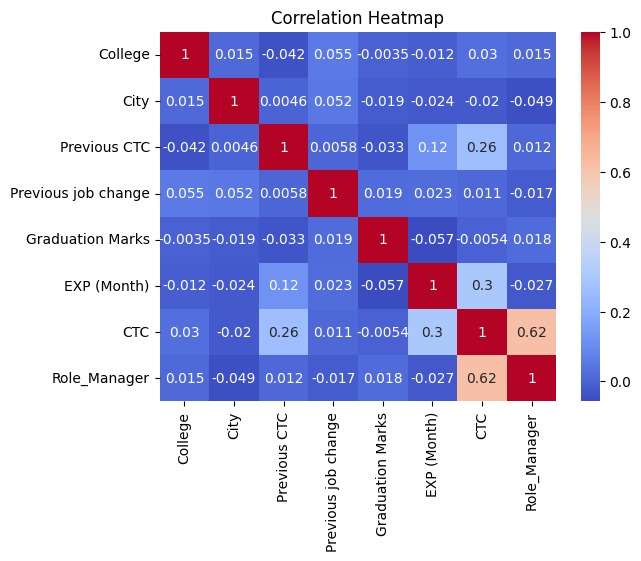

In [40]:
plt.title("Correlation Heatmap")
sns.heatmap(df.corr(), annot = True, cmap="coolwarm")

#### Outlier Detection

<Axes: ylabel='CTC'>

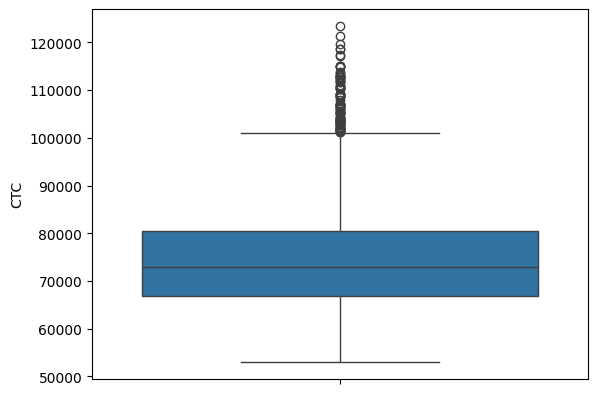

In [41]:
sns.boxplot(df['CTC'])

#### Removing The Outliers

In [42]:
q1=df['CTC'].quantile(0.25)

In [43]:
q3=df['CTC'].quantile(0.75)

In [44]:
iqr= q3-q1

In [45]:
lower_bound= q1-1.5*iqr
upper_bound= q3+1.5*iqr

In [46]:
df=df[(df['CTC']>=lower_bound) & (df['CTC']<=upper_bound)]

<Axes: ylabel='CTC'>

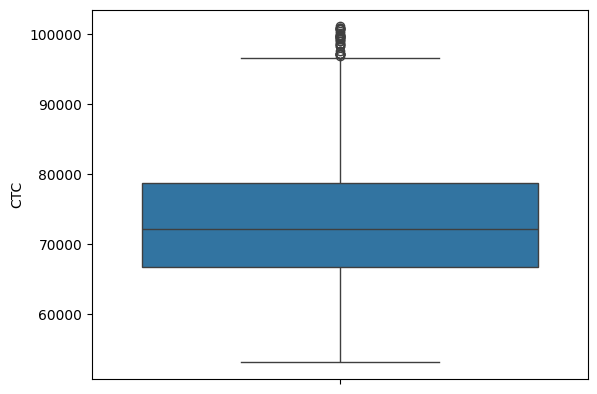

In [47]:
sns.boxplot(df['CTC'])

#### Visualizing the Data

<Axes: xlabel='CTC', ylabel='Count'>

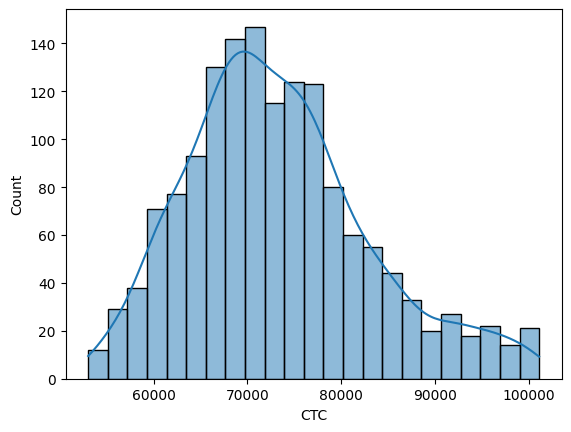

In [48]:
sns.histplot(df['CTC'], kde = True)

<Axes: xlabel='EXP (Month)', ylabel='CTC'>

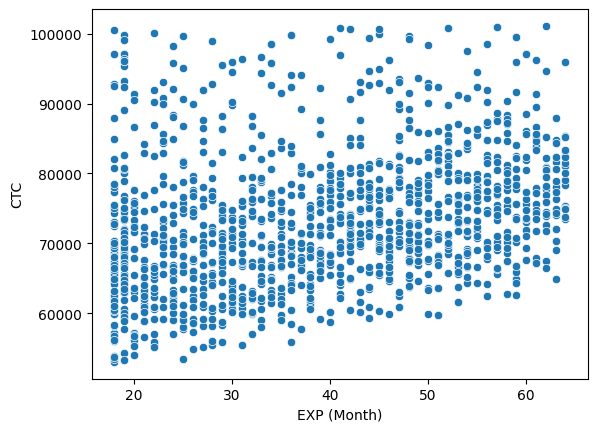

In [49]:
sns.scatterplot(x=df['EXP (Month)'], y= df['CTC'])

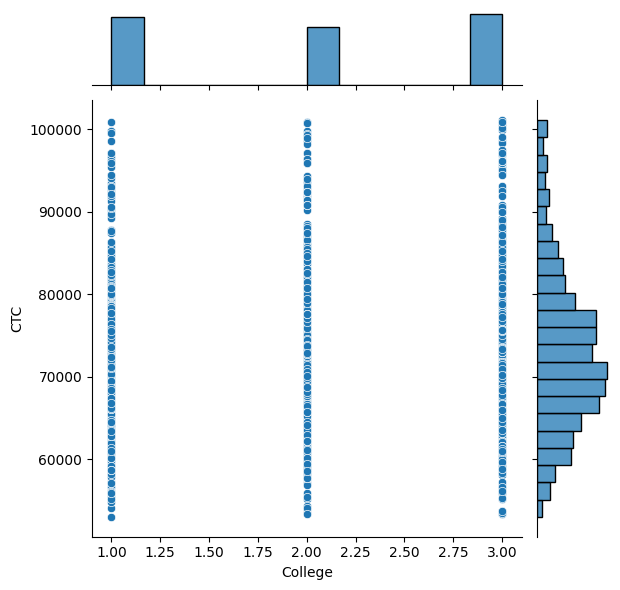

In [50]:
sns.jointplot(x = "College", y = "CTC", data =df)

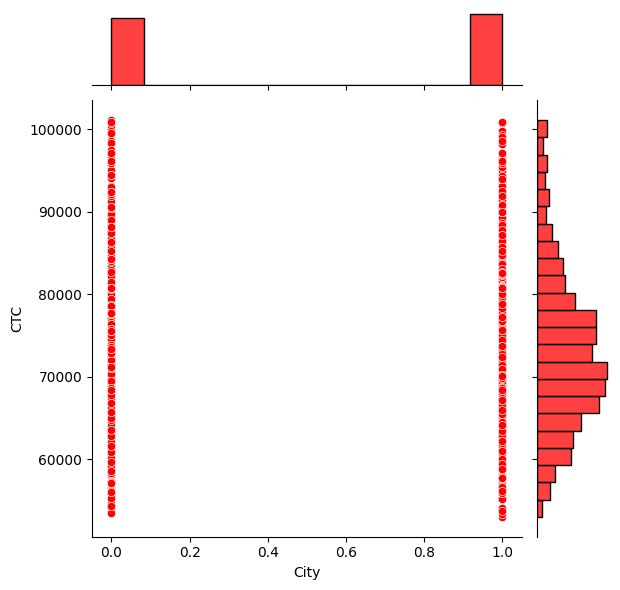

In [51]:
sns.jointplot(x = "City", y = "CTC", data = df, color = 'Red')

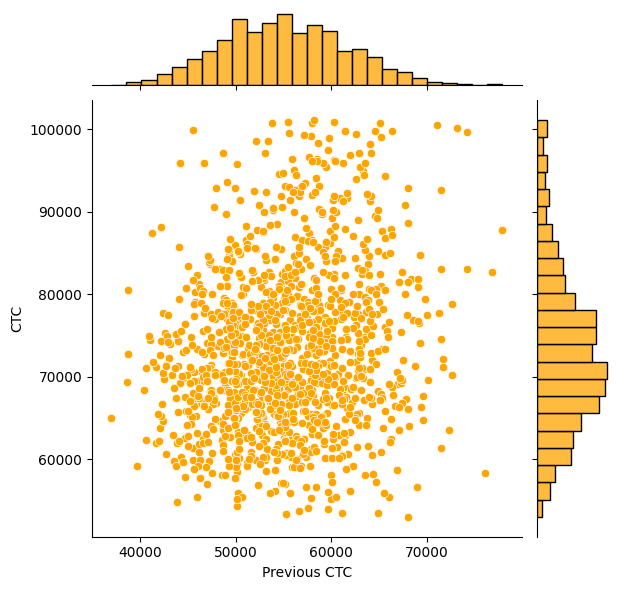

In [52]:
sns.jointplot(x = "Previous CTC", y = "CTC", data = df, color = 'Orange')

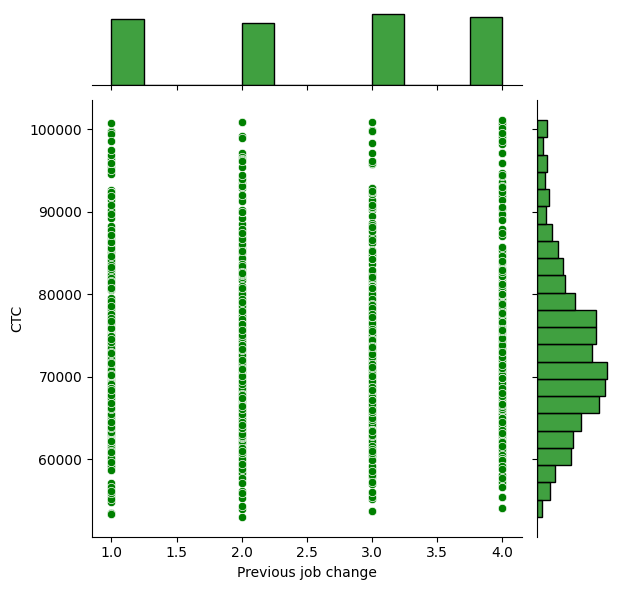

In [53]:
sns.jointplot(x = "Previous job change", y = "CTC", data = df, color = 'Green')

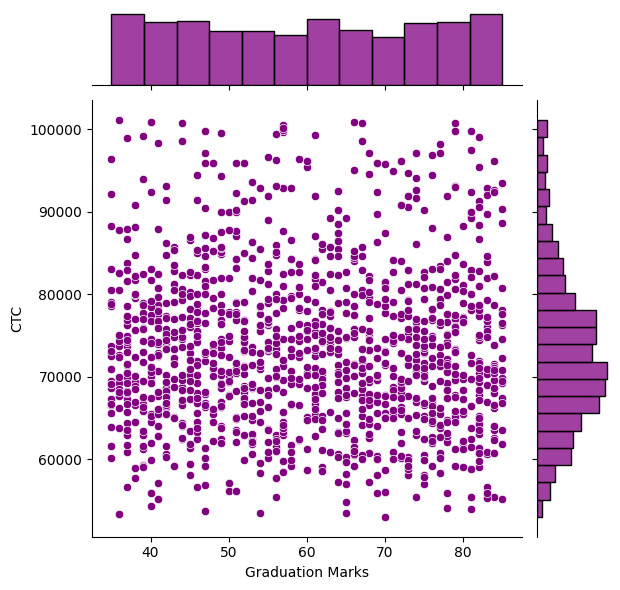

In [54]:
sns.jointplot(x = "Graduation Marks", y = "CTC", data = df, color = 'Purple')

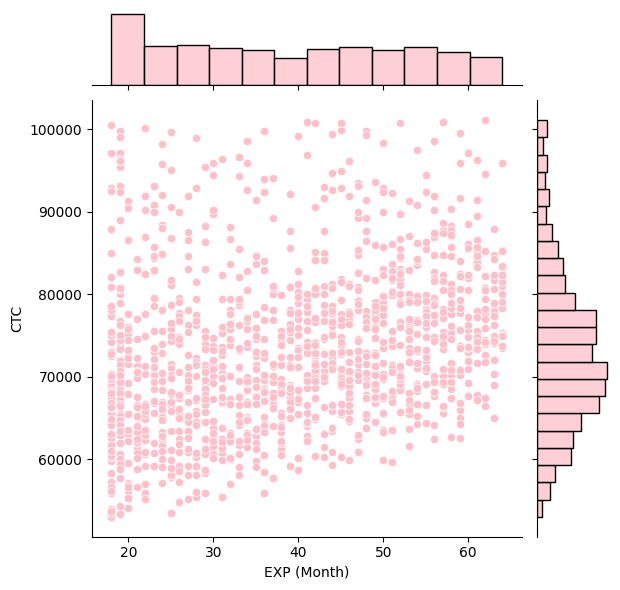

In [55]:
sns.jointplot(x = "EXP (Month)", y = "CTC", data = df, color = 'Pink')

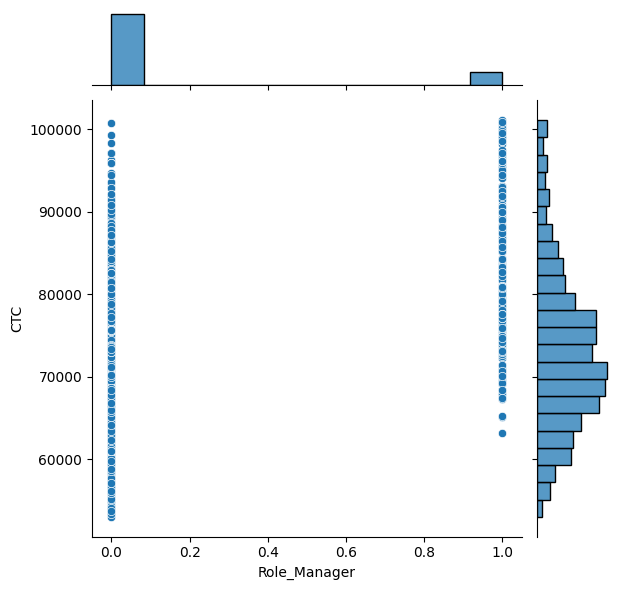

In [56]:
sns.jointplot(x = "Role_Manager", y = "CTC", data = df)

#### Preparing the data for test-train split

In [57]:
x_multi = df.drop(columns = ['CTC','Graduation Marks'], axis = 1)

In [58]:
x_multi.head()

,College,City,Previous CTC,Previous job change,EXP (Month),Role_Manager
0,2,0,55523,3,19,1
1,2,0,57081,1,18,0
2,1,0,60347,2,28,0
3,1,0,49010,2,33,0
4,3,0,57879,4,32,0


In [59]:
y_multi = np.log(df['CTC'])

In [60]:
y_multi.head()

0    11.176137
1    11.127337
2    11.248491
3    11.315596
4    11.210170
Name: CTC, dtype: float64

#### Train-Test split

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
x_train, x_test, y_train, y_test = train_test_split(x_multi, y_multi, test_size = 0.2, random_state = 0)

In [63]:
# Displaying the no. of rows and columns of independent and dependent train variables

In [64]:
x_train.shape, y_train.shape

((1196, 6), (1196,))

In [65]:
# Displaying the no. of rows and columns of independent and dependent test variables

In [66]:
x_test.shape, y_test.shape

((299, 6), (299,))

#### Importing Linear Regression Model

In [67]:
from sklearn.linear_model import LinearRegression

In [68]:
lr=LinearRegression()

In [69]:
lr.fit(x_train, y_train)

LinearRegression()

In [70]:
print(lr.intercept_, lr.coef_)

10.828763911593056 [ 4.52338821e-03  1.92572431e-03  3.71474858e-06 -7.88554682e-04
  3.25836537e-03  1.78869324e-01]


In [71]:
y_pred=lr.predict(x_test)

#### Model Accuracy using Linear Regression

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [73]:
print("Mean absolute error for test data:", mean_absolute_error(y_test, y_pred))

Mean absolute error for test data: 0.08041322645308209


In [74]:
print("Mean squared error for test data:", mean_squared_error(y_test, y_pred))

Mean squared error for test data: 0.00974767038846165


In [75]:
print("R2 score for test data:", r2_score(y_test, y_pred))

R2 score for test data: 0.4293119986693307


#### Importing Random Forest Regressor

In [76]:
from sklearn.ensemble import RandomForestRegressor

In [77]:
rf=RandomForestRegressor()

In [78]:
rf.fit(x_train, y_train)

RandomForestRegressor()

In [79]:
y_pred_rf=rf.predict(x_test)

#### Model Accuracy using Random Forest

In [80]:
print("Mean absolute error for test data:", mean_absolute_error(y_test, y_pred_rf))

Mean absolute error for test data: 0.06970551471832141


In [81]:
print("Mean squared error for test data:", mean_squared_error(y_test, y_pred_rf))

Mean squared error for test data: 0.007875417528068475


In [82]:
print("R2 score for test data:", r2_score(y_test, y_pred_rf))

R2 score for test data: 0.538925085725307


#### HyperParameter Tuning using GridSearch

In [83]:
from sklearn.model_selection import GridSearchCV

In [84]:
param_grid={'n_estimators': [100,200], 'max_depth': [5,10,None]}

In [85]:
grid=GridSearchCV(rf,param_grid, cv=5)

In [86]:
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, None],
                         'n_estimators': [100, 200]})

In [87]:
y_pred_rf_grid = grid.predict(x_test)

#### Model Accuracy using Grid Search

In [88]:
print("Mean absolute error for test data:", mean_absolute_error(y_test, y_pred_rf_grid))

Mean absolute error for test data: 0.07026044970287797


In [89]:
print("Mean squared error for test data:", mean_squared_error(y_test, y_pred_rf_grid))

Mean squared error for test data: 0.007833727356770626


In [90]:
print("R2 score for test data:", r2_score(y_test, y_pred_rf_grid))

R2 score for test data: 0.5413658823038685


In [91]:
best_model= grid.best_estimator_

In [92]:
best_model

RandomForestRegressor(max_depth=10, n_estimators=200)

#### Important features for determining CTC

In [93]:
importance = best_model.feature_importances_

In [94]:
features = x_test.columns

<Axes: >

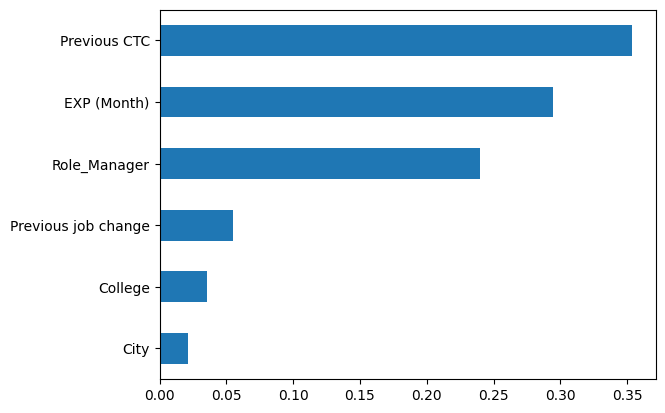

In [95]:
feat_imp = pd.Series(importance, index=features).sort_values()
feat_imp.plot(kind='barh')

#### Residual Analysis

In [96]:
residuals=y_test-best_model.predict(x_test)

<Axes: ylabel='CTC'>

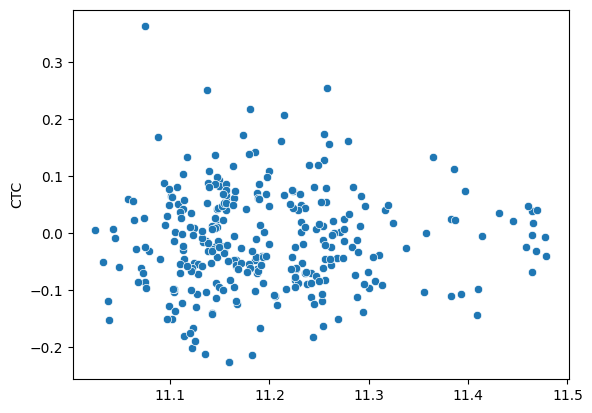

In [97]:
sns.scatterplot(x=best_model.predict(x_test) ,y=residuals)